In [41]:
import os
import json

DIR_PATH = 'data'

personas = []
for filename in os.listdir(DIR_PATH):
    file_path = os.path.join(DIR_PATH, filename)
    with open(file_path, 'r', encoding='utf-8') as file:
        persona = json.load(file)
    personas.append(persona)

In [42]:
# Persona
persona_total = len(personas)
print(f"The total number of personas is {persona_total}")

The total number of personas is 132


In [43]:
# Session
session_count = []
for persona in personas:
    session_count.append(len(persona["sessions"]))
session_total = sum(session_count)
session_avg = sum(session_count) / len(session_count)
print(f"The total number of sessions is {session_total}")
print(f"The average sessions per individual is {session_avg}")

The total number of sessions is 2860
The average sessions per individual is 21.666666666666668


In [44]:
# Utterance
utter_count = []
for persona in personas:
    session_utter_count = 0
    for session in persona['sessions']:
        session_utter_count += len(session['turns'])
    utter_count.append(session_utter_count)
utter_total = sum(utter_count)
utter_avg = sum(utter_count) / persona_total
print(f"The total number of utterances is {utter_total}")
print(f"The average utterances per persona is {utter_avg}")

The total number of utterances is 18481
The average utterances per persona is 140.00757575757575


In [45]:
# Service
service_distribution = {}
for persona in personas:
    for session in persona['sessions']:
        service = session['service']
        if service in service_distribution:
            service_distribution[service] += 1
        else:
            service_distribution[service] = 1

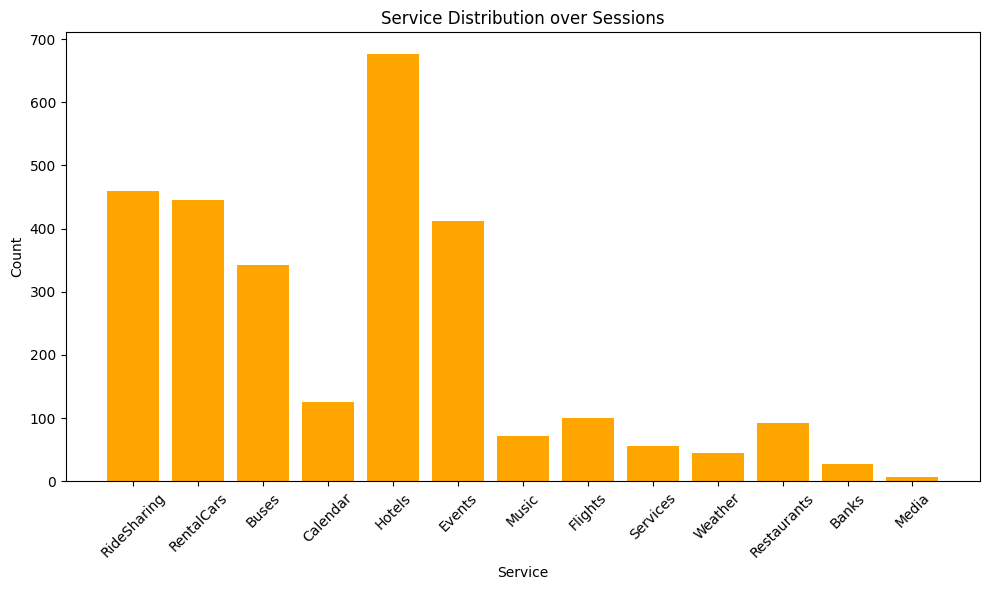

In [46]:
import matplotlib.pyplot as plt

# Create a bar chart to visualize the service counts
services = list(service_distribution.keys())
counts = list(service_distribution.values())

plt.figure(figsize=(10, 6))
plt.bar(services, counts, color='orange')
plt.xlabel('Service')
plt.ylabel('Count')
plt.title('Service Distribution over Sessions')
plt.xticks(rotation=45)
plt.tight_layout()

# Save the plot as an image file
plt.savefig('service_distribution.png')

# Display the plot
plt.show()
